Appliances detected: ['Air_Conditioning', 'Oven', 'Computer', 'Washing_Machine', 'Dishwasher', 'Fridge', 'Lights', 'TV', 'Microwave', 'Heater']

Processing: Air_Conditioning
Model saved: /content/baseline_linear_models/Air_Conditioning_baseline_model.pkl
MAE: 0.757255924876371
RMSE: 0.8734192821788136
R2 Score: -0.013921881721663754


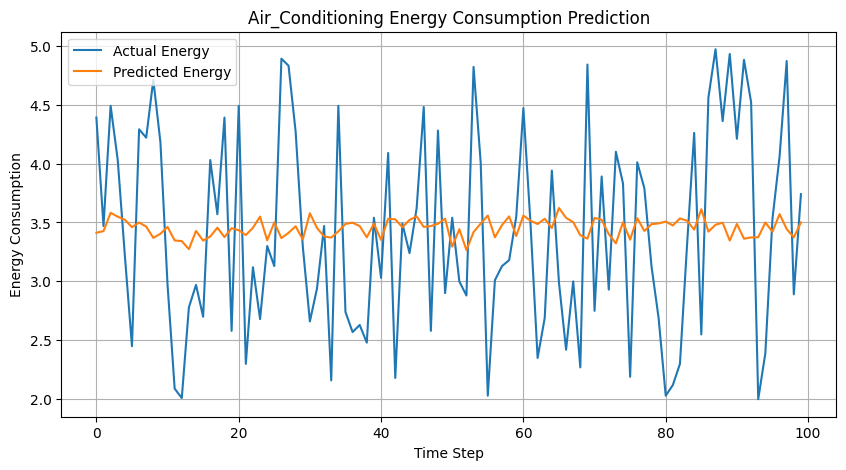


Processing: Oven
Model saved: /content/baseline_linear_models/Oven_baseline_model.pkl
MAE: 0.4687466190261235
RMSE: 0.5370192394637899
R2 Score: -0.00514666522259577


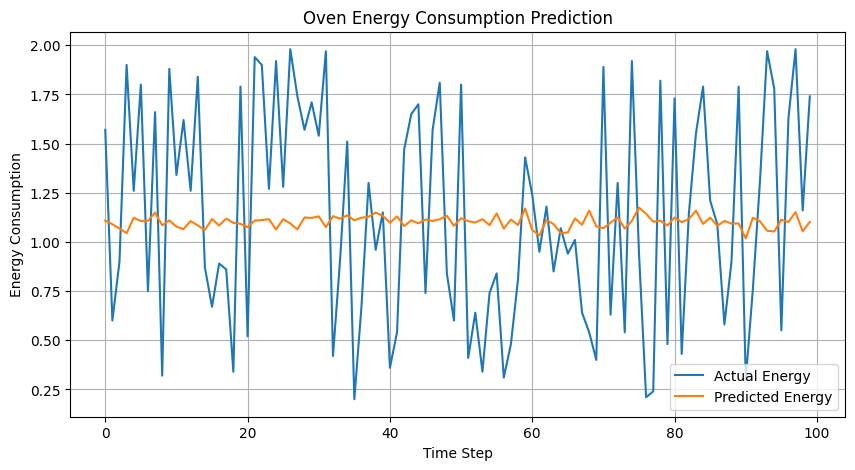


Processing: Computer
Model saved: /content/baseline_linear_models/Computer_baseline_model.pkl
MAE: 0.4719628378201795
RMSE: 0.5404242288964823
R2 Score: -0.007139542603323168


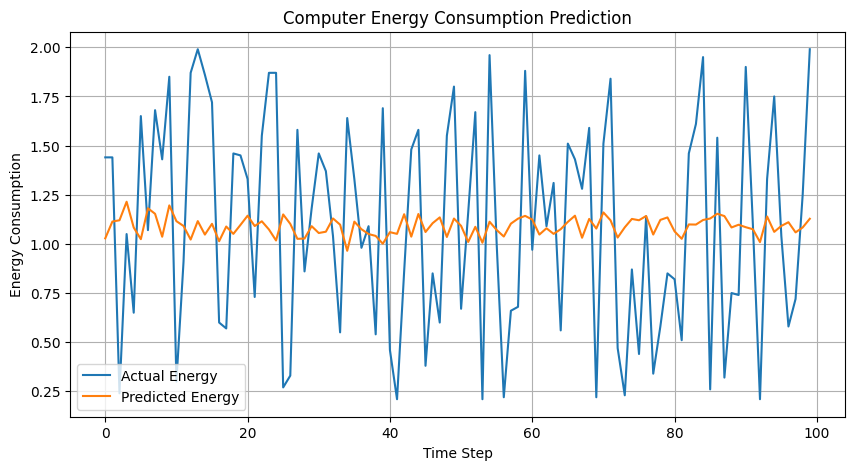


Processing: Washing_Machine
Model saved: /content/baseline_linear_models/Washing_Machine_baseline_model.pkl
MAE: 0.48135477142199184
RMSE: 0.5471791604734735
R2 Score: -0.026857470720047516


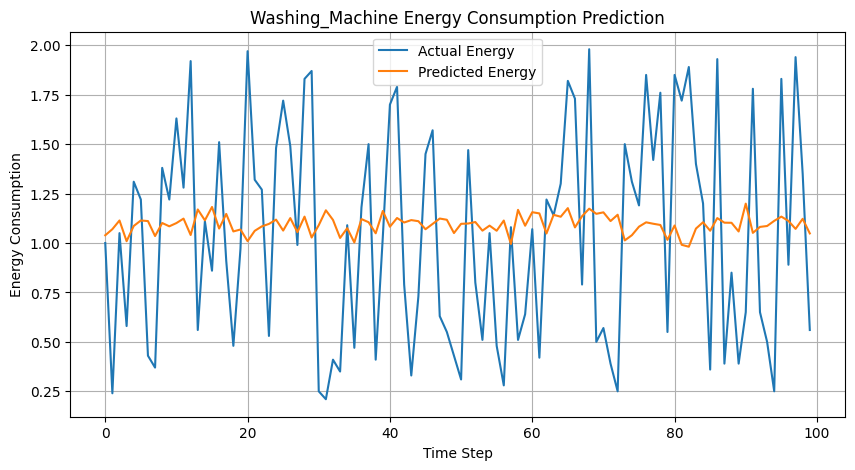


Processing: Dishwasher
Model saved: /content/baseline_linear_models/Dishwasher_baseline_model.pkl
MAE: 0.4380225579326637
RMSE: 0.5076311059091868
R2 Score: -0.018272663506271547


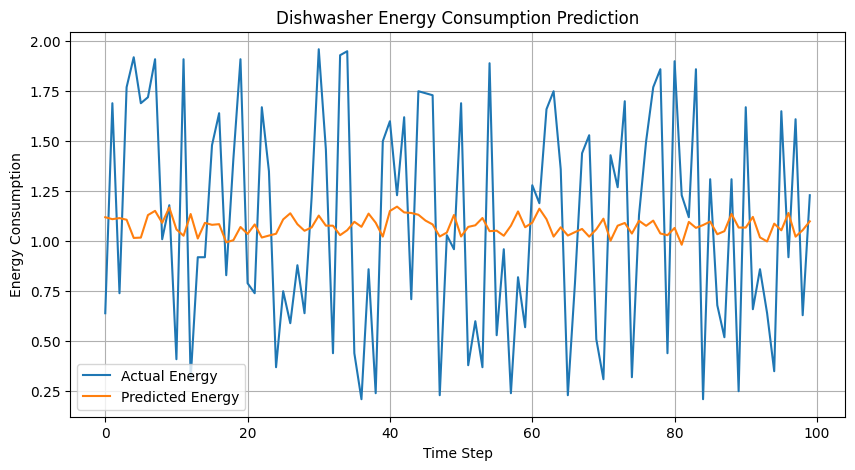


Processing: Fridge
Model saved: /content/baseline_linear_models/Fridge_baseline_model.pkl
MAE: 0.09862252648705226
RMSE: 0.11509391046295876
R2 Score: 3.811000679865284e-05


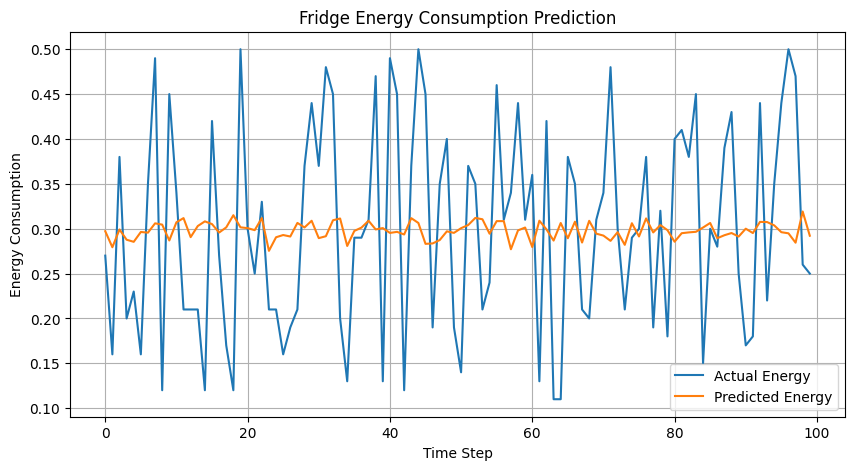


Processing: Lights
Model saved: /content/baseline_linear_models/Lights_baseline_model.pkl
MAE: 0.4484420070944444
RMSE: 0.518444411181202
R2 Score: -0.0027223902278890044


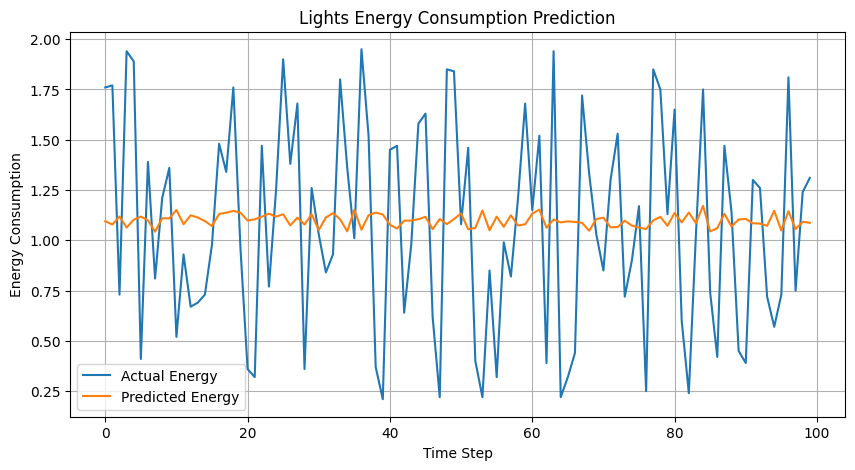


Processing: TV
Model saved: /content/baseline_linear_models/TV_baseline_model.pkl
MAE: 0.45149904849645534
RMSE: 0.5190411656322267
R2 Score: -0.0095092747088934


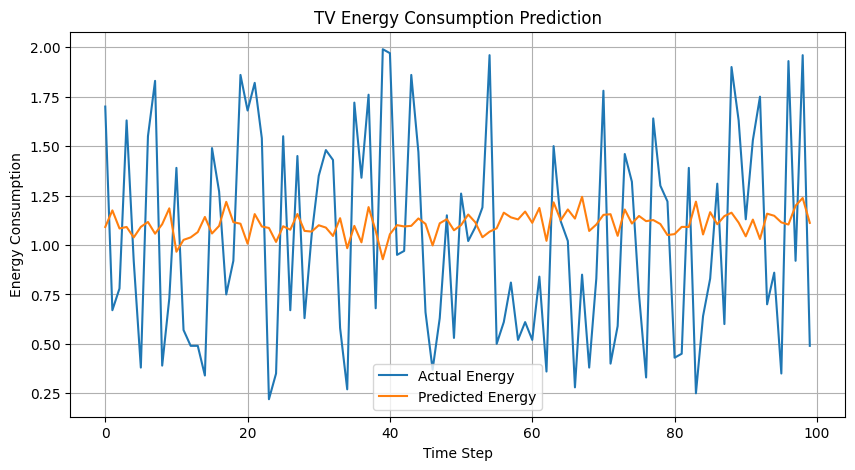


Processing: Microwave
Model saved: /content/baseline_linear_models/Microwave_baseline_model.pkl
MAE: 0.4540840633781727
RMSE: 0.5216655402699139
R2 Score: -0.00837122025114101


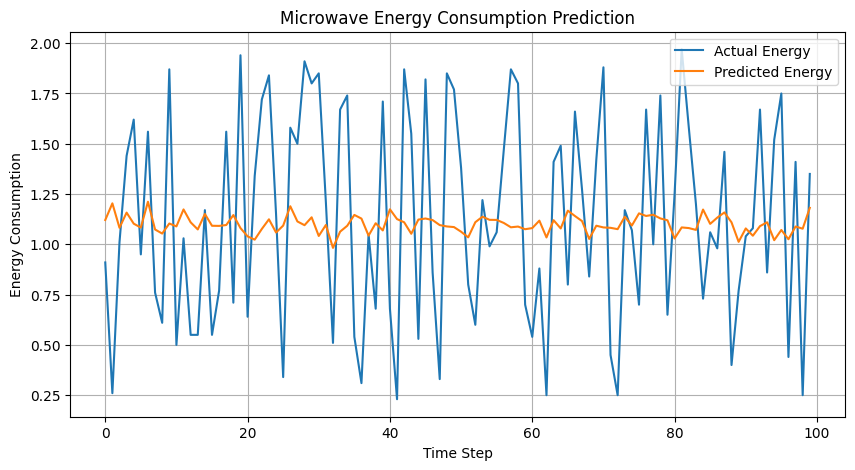


Processing: Heater
Model saved: /content/baseline_linear_models/Heater_baseline_model.pkl
MAE: 0.8258629692376727
RMSE: 0.9339156976324975
R2 Score: -0.012876162490610188


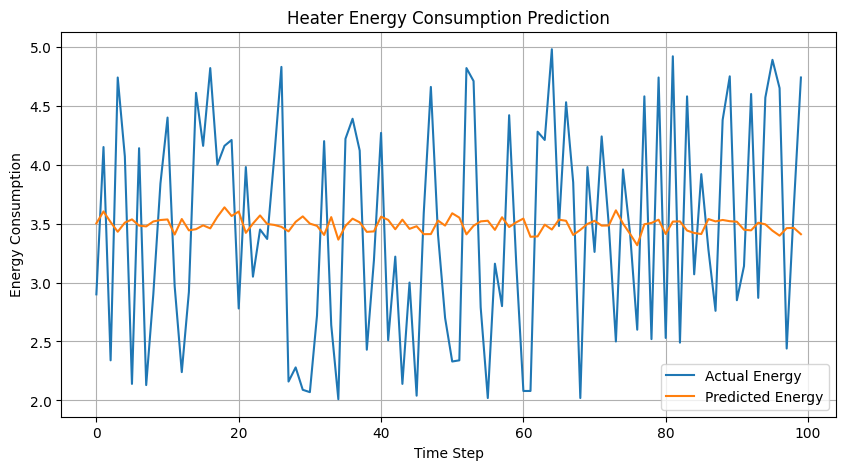

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Path of dataset folder
data_path = "/content/appliance_datasets"

# Folder to save trained models
model_path = "/content/baseline_linear_models"
os.makedirs(model_path, exist_ok=True)

# Detect appliances automatically
appliances = []

for file in os.listdir(data_path):
    if file.startswith("X_train_"):
        appliance = file.replace("X_train_", "").replace(".csv", "")
        appliances.append(appliance)

print("Appliances detected:", appliances)

# Loop through each appliance
for appliance in appliances:

    print("\nProcessing:", appliance)

    # -----------------------------
    # LOAD DATA
    # -----------------------------
    X_train = pd.read_csv(f"{data_path}/X_train_{appliance}.csv")
    X_test = pd.read_csv(f"{data_path}/X_test_{appliance}.csv")

    y_train = pd.read_csv(f"{data_path}/y_train_{appliance}.csv").values.ravel()
    y_test = pd.read_csv(f"{data_path}/y_test_{appliance}.csv").values.ravel()

    # -----------------------------
    # HANDLE CATEGORICAL DATA
    # -----------------------------
    X_train = pd.get_dummies(X_train)
    X_test = pd.get_dummies(X_test)

    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # -----------------------------
    # MODIFY SOME VALUES
    # -----------------------------
    X_train_modified = X_train.copy()

    for col in X_train_modified.select_dtypes(include=np.number).columns:
        X_train_modified[col] = X_train_modified[col] * 1.02

    # -----------------------------
    # TRAIN MODEL
    # -----------------------------
    model = LinearRegression()
    model.fit(X_train_modified, y_train)

    # -----------------------------
    # SAVE MODEL
    # -----------------------------
    model_file = f"{model_path}/{appliance}_baseline_model.pkl"
    joblib.dump(model, model_file)

    print("Model saved:", model_file)

    # -----------------------------
    # PREDICTION
    # -----------------------------
    y_pred = model.predict(X_test)

    # -----------------------------
    # METRICS
    # -----------------------------
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

    # -----------------------------
    # PLOT LINE GRAPH
    # -----------------------------
    plt.figure(figsize=(10,5))

    plt.plot(range(100), y_test[:100], label="Actual Energy")
    plt.plot(range(100), y_pred[:100], label="Predicted Energy")

    plt.title(f"{appliance} Energy Consumption Prediction")
    plt.xlabel("Time Step")
    plt.ylabel("Energy Consumption")

    plt.legend()
    plt.grid(True)

    plt.show()

In [10]:
!zip -r baseline_models.zip /content/baseline_linear_models

  adding: content/baseline_linear_models/ (stored 0%)
  adding: content/baseline_linear_models/TV_baseline_model.pkl (deflated 27%)
  adding: content/baseline_linear_models/Oven_baseline_model.pkl (deflated 27%)
  adding: content/baseline_linear_models/Washing_Machine_baseline_model.pkl (deflated 27%)
  adding: content/baseline_linear_models/Lights_baseline_model.pkl (deflated 27%)
  adding: content/baseline_linear_models/Heater_baseline_model.pkl (deflated 27%)
  adding: content/baseline_linear_models/Fridge_baseline_model.pkl (deflated 27%)
  adding: content/baseline_linear_models/Dishwasher_baseline_model.pkl (deflated 28%)
  adding: content/baseline_linear_models/Computer_baseline_model.pkl (deflated 27%)
  adding: content/baseline_linear_models/Microwave_baseline_model.pkl (deflated 27%)
  adding: content/baseline_linear_models/Air_Conditioning_baseline_model.pkl (deflated 27%)


In [11]:
from google.colab import files
files.download("baseline_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>